In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/stream_macroinvertebrates'))

['Asellus sp', 'Gammarus sp', 'Limnius sp', 'Elmis sp', 'Hydropsychidae sp', 'Erpobdella sp', 'Baetidae sp', 'Leuctra sp', 'Lymnea sp', 'Leptophlebiidae sp', 'Ephemerellidae', 'Sericostomatidae sp', 'Sphaerium sp', 'Simuliidae sp', 'Oligochaeta sp', 'Nemoura sp', 'Sialis sp']


In [ ]:
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/stream_macroinvertebrates/Ephemerellidae'))

[]


In [33]:
print(os.listdir('/content/drive/MyDrive/Colab Notebooks'))

['ST1_Week_7_Tut_Lab.ipynb', 'Week6_lab.ipynb', 'Untitled0.ipynb', 'stream_macroinvertebrates', 'insects_dataset', 'macroinvertebrates_classifier.h5', 'test_images']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



# Stream Macroinvertebrates Image Classification
# ==================================
### This notebook demonstrates how to:
### 1. Load your dataset organized by class folders (without predefined splits)
### 2. Perform train/validation split in code
### 3. Augment data during training
### 4. Build transfer learning model with MobileNetV2 pretrained on ImageNet
### 5. Train, evaluate, and predict on new images


In [ ]:
%cd /content/drive/MyDrive/Colab\ Notebooks

/content/drive/MyDrive/Colab Notebooks


In [ ]:
!ls

ST1_Week_7_Tut_Lab.ipynb   Untitled0.ipynb
stream_macroinvertebrates  Week6_lab.ipynb


In [ ]:
import os
import shutil

# Base paths
src = '/content/drive/MyDrive/Colab Notebooks/stream_macroinvertebrates'
base = '/content/drive/MyDrive/Colab Notebooks/insects_dataset'

# Create train and test folders for your 3 species
species = ['Ephemerellidae', 'Gammarus sp', 'Leuctra sp']

for sp in species:
    os.makedirs(f'{base}/train_data/{sp}', exist_ok=True)
    os.makedirs(f'{base}/test_data/{sp}', exist_ok=True)

print("All folders created!")

All folders created!


In [ ]:
import random

for sp in species:
    src_folder = f'{src}/{sp}'
    all_images = os.listdir(src_folder)
    test_images = random.sample(all_images, 5)

    for img in test_images:
        shutil.move(f'{src_folder}/{img}', f'{base}/test_data/{sp}/{img}')

    # Move remaining to train_data
    remaining = os.listdir(src_folder)
    for img in remaining:
        shutil.move(f'{src_folder}/{img}', f'{base}/train_data/{sp}/{img}')

print("Images moved successfully!")

Images moved successfully!


In [ ]:
%cd /content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities

[Errno 2] No such file or directory: '/content/drive/MyDrive/2026_Teaching/ST1/Week_7_Tut_Lab_Activities'
/content


In [ ]:
!ls

sample_data



## Step 0: Data Preparation
  
1.   Set the run time to one of the GPU options by selecting Runtime/Change Runtime type/...

2. Set the working folder for google colab notebook to the folder in the google drive.

3. Download stream invertebrates dataset from Kaggle and unzip it in google drive folder. You will find stream macroinvertebrates dataset in the unzipped archive folder ( You can do this outside colab as well).

4. Manually create a insects_dataset folder in Assets folder.

5. The images for each insect species in a separate folder, with folder name as the species name.

6. Pick any three insect species from the unzipped archive folder. The three species you select need to be other than the three species shown in this demo.

6. Create two new folders train_data and test_data in insects_dataset folder you just created in Step 4.

7. Move five images from each species you have selected into the test_data folder. Please note that they need to be moved, not copied. In total you would have 15 images in the test_data folder (5 images corresponding to each species).

8. Move remaining folders into train_data folder. Please note that you will not move each image, but move each folder containing remaining images into the train_data folder. After moving you will see three folders in train_data folder, with each folder containing several insect images corresponding to each insect species.



In [ ]:
#! git clone https://www.kaggle.com/datasets/kennethtm/stream-macroinvertebrates/data


In [ ]:
#!unzip archive.zip

In [ ]:
#Step 1
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

# === USER VARIABLES ===

# Path to your dataset folder organized by class subfolders
#DATASET_DIR = 'dataset/' #Change to your dataset path
DATASET_DIR = '/content/drive/MyDrive/Colab Notebooks/insects_dataset/train_data'
# Image input size and batch size for training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123  # For deterministic shuffling/splitting

# === STEP 1: Load dataset and split into train/validation ===

print("Loading dataset with 80/20 train-validation split...")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes found: {class_names}")




Loading dataset with 80/20 train-validation split...
Found 1064 files belonging to 3 classes.
Using 852 files for training.
Found 1064 files belonging to 3 classes.
Using 212 files for validation.
Classes found: ['Ephemerellidae', 'Gammarus sp', 'Leuctra sp']


In [ ]:
# === STEP 2: Optimize dataset performance ===

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

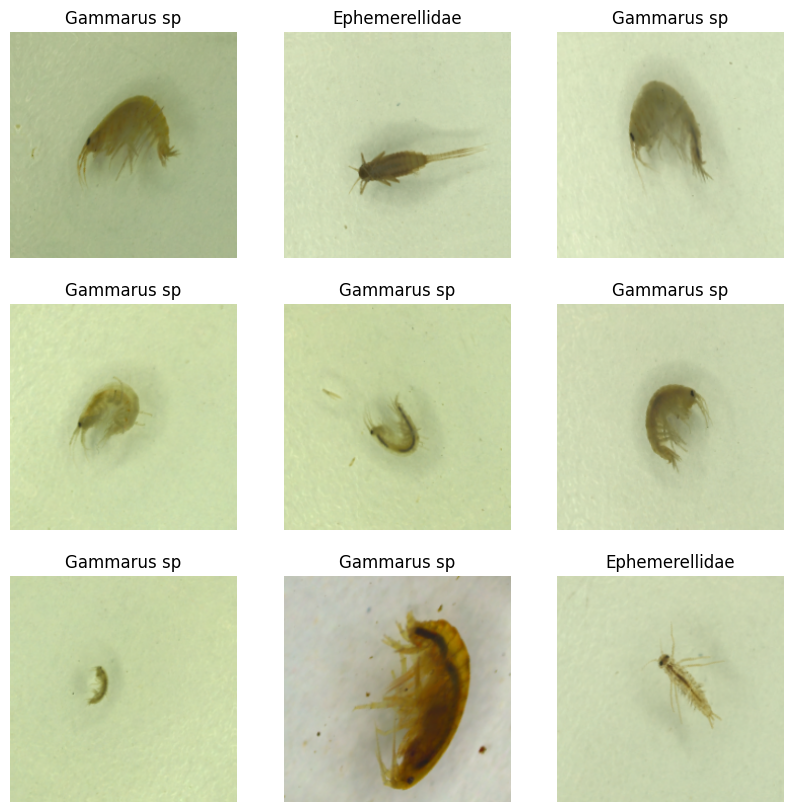

In [ ]:
# === STEP 3: Data augmentation (recommended) ===

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Visualize some augmented images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
# === STEP 4: Build transfer learning model ===

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze the base model initially

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:

# === STEP 5: Train the model ===

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 30s 769ms/step - accuracy: 0.8873 - loss: 0.3291 - val_accuracy: 0.9575 - val_loss: 0.1305
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 413ms/step - accuracy: 0.9589 - loss: 0.1531 - val_accuracy: 0.9623 - val_loss: 0.0889
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 399ms/step - accuracy: 0.9707 - loss: 0.0966 - val_accuracy: 0.9764 - val_loss: 0.0673
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 21s 403ms/step - accuracy: 0.9765 - loss: 0.0790 - val_accuracy: 0.9858 - val_loss: 0.0509
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 410ms/step - accuracy: 0.9812 - loss: 0.0608 - val_accuracy: 0.9953 - val_loss: 0.0449
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 376ms/step - accuracy: 0.9836 - loss: 0.0541 - val_accuracy: 0.9906 - val_loss: 0.0367
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 450ms/step - accuracy: 0.9859 - loss: 0.0453 - val_accuracy: 0.9953 - val_loss: 0.0342
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 417ms/step - accuracy: 0.9836 - loss: 0.0489 - val_accu

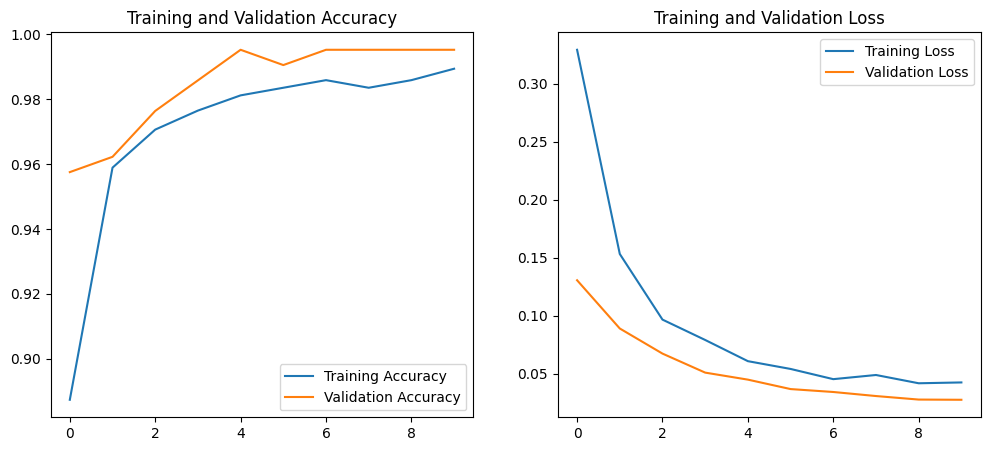

In [ ]:
# === STEP 6: Plot training curves ===

# Re-extracting from history to ensure correct length for initial EPOCHS
initial_acc = history.history['accuracy']
initial_val_acc = history.history['val_accuracy']
initial_loss = history.history['loss']
initial_val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, initial_acc, label='Training Accuracy')
plt.plot(epochs_range, initial_val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, initial_loss, label='Training Loss')
plt.plot(epochs_range, initial_val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# === STEP 7: Evaluate on validation set ===

val_loss, val_acc = model.evaluate(val_ds)
print(f'Validation accuracy: {val_acc*100:.2f}%')

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step - accuracy: 0.9953 - loss: 0.0275
Validation accuracy: 99.53%


In [ ]:
# === STEP 9: Save the trained model ===
%cd "/content/drive/MyDrive/Colab Notebooks"
model.save("macroinvertebrates_classifier.h5")
print("Done")

/content/drive/MyDrive/Colab Notebooks
Done


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


<Figure size 1200x1200 with 0 Axes>

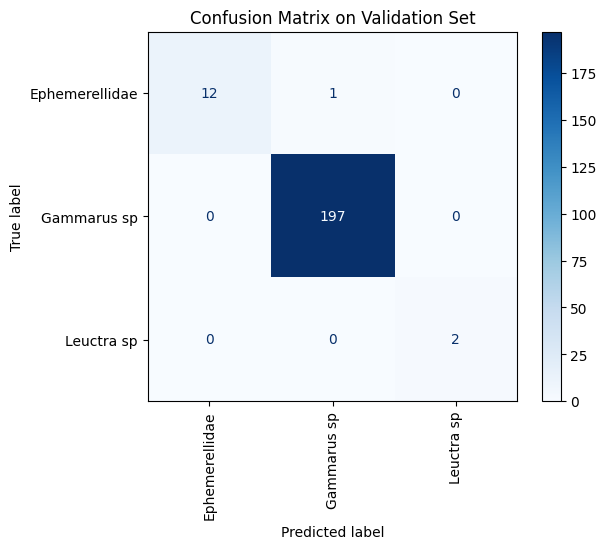

Weighted Precision: 0.9953
Weighted Recall:    0.9953
Weighted F1-score:  0.9952


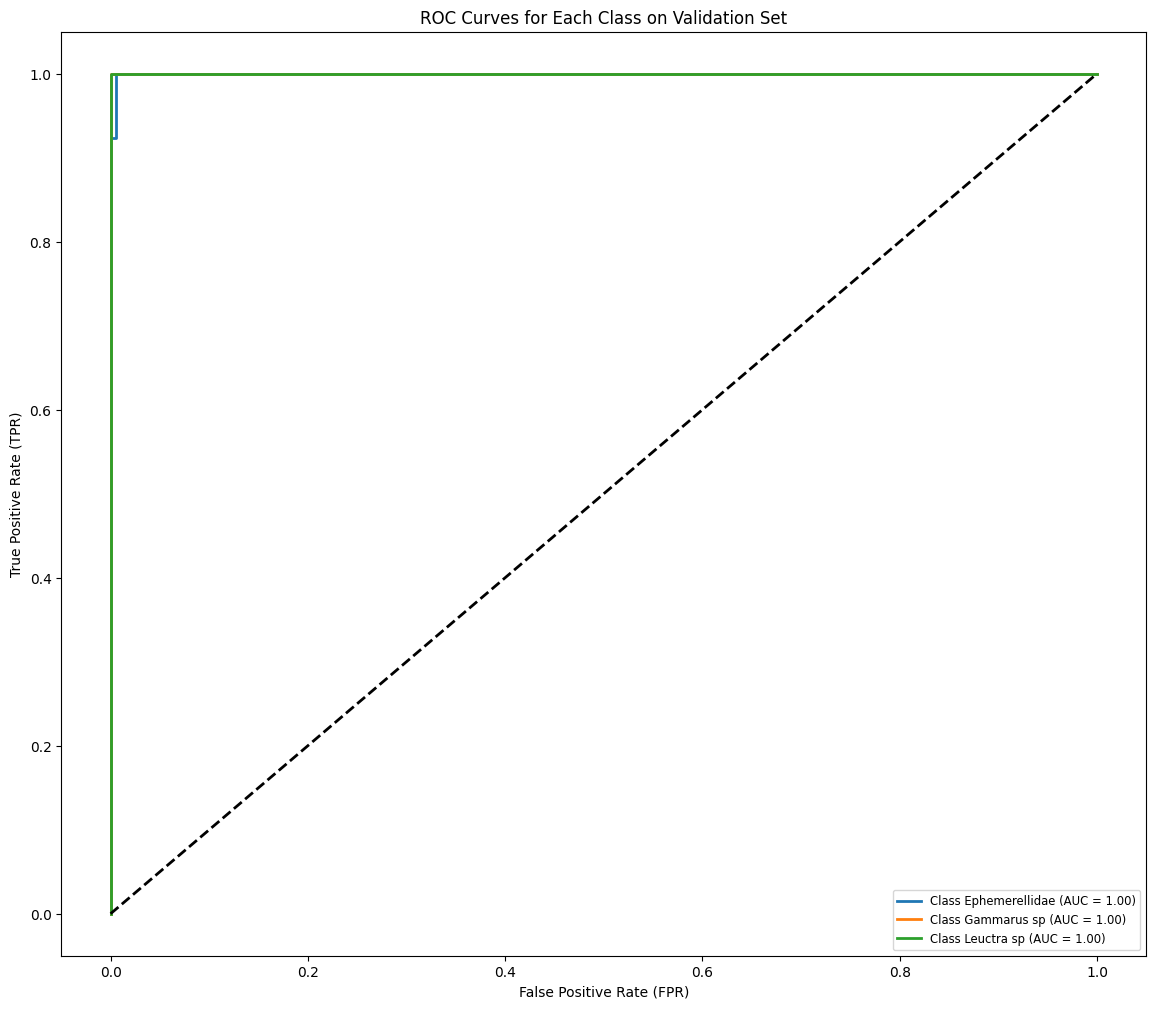

In [ ]:
# === STEP 10: Evaluate model with confusion matrix, precision, recall, F1-score ===

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
import os

# Step 10.1: Aggregate predictions and true labels from validation dataset
y_true = []
y_pred = []
y_scores = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_scores.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

# Step 10.2: Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(12,12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix on Validation Set')
plt.show()

# Step 10.3: Precision, Recall, F1-score (weighted average)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1-score:  {f1:.4f}")

# Step 10.4: Multi-class ROC curves and AUC

# Binarize the labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(14, 12))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves for Each Class on Validation Set")
plt.legend(loc="lower right", fontsize='small')
plt.show()



In [35]:
# === STEP 12: Inference on new images in 'test_images' folder ===

#TEST_IMAGE_DIR = 'test_images'
TEST_IMAGE_DIR = '/content/drive/MyDrive/Colab Notebooks/test_images'
os.makedirs(TEST_IMAGE_DIR, exist_ok=True)

def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # batch size 1
    return img_array

def predict_new_images(test_dir):
    img_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"No images found in '{test_dir}'. Please add some images and rerun.")
        return

    for img_file in img_files:
        path = os.path.join(test_dir, img_file)
        img_arr = load_and_preprocess_image(path)
        preds = model.predict(img_arr)
        pred_idx = np.argmax(preds[0])
        confidence = preds[0][pred_idx]

        print(f"Original Image: {img_file} --> Predicted: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        img = image.load_img(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {class_names[pred_idx]} ({confidence*100:.2f}%)")
        plt.show()

print("Running inference on images from 'test_images' folder...")
predict_new_images(TEST_IMAGE_DIR)


Output hidden; open in https://colab.research.google.com to view.